## Cell 1: Install Dependencies

In [2]:
!pip install -q cerebras_cloud_sdk
!pip install -q "datasets>=2.18.0" "python-constraint>=1.4.0" "pandas>=2.0.0" "tqdm>=4.66.0" "z3-solver>=4.12.0" "seaborn>=0.13.0" "matplotlib>=3.7.0"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.8/97.8 kB 2.4 MB/s eta 0:00:00a 0:00:01
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.7/31.7 MB 43.0 MB/s eta 0:00:00:00:0100:01


## Cell 2: Imports

In [3]:
import os
import json
import re
import time
import gc
import traceback
import seaborn as sns
import matplotlib.pyplot as plt
from typing import Optional, Dict, List, Tuple, Any
from concurrent.futures import ThreadPoolExecutor
from collections import defaultdict, Counter
from dataclasses import dataclass, field

import numpy as np
import pandas as pd
from tqdm.auto import tqdm
from constraint import Problem, AllDifferentConstraint
from z3 import (Solver, Bool, Int, And, Or, Not, Implies, If,
                sat, unsat, Distinct, IntVal, BoolVal, Sum,
                Optimize, ArithRef, BoolRef,
                AtMost, AtLeast, PbEq, PbLe, PbGe,
                Function, IntSort, BoolSort, EnumSort,
                Const, Consts, ForAll, Exists,
                RealVal, Real, simplify, is_true, is_false,
                Array, Select, Store)
from cerebras.cloud.sdk import Cerebras

## Cell 3: Configuration & Model Loading

In [4]:
class Config:
    # Cerebras API settings
    CEREBRAS_API_KEY = "csk-d3j2k6mdkp2djh9r8e3ywry2wptd3exw69yrhdfywwwyepdv"
    MODEL_NAME = "gpt-oss-120b"

    # Generation settings
    MAX_NEW_TOKENS = 16384
    TEMPERATURE = 0.3
    TOP_P = 0.8

    # Benchmark settings
    NUM_PUZZLES = 25
    MAX_REFINEMENT_ROUNDS = 3
    SEED = 42

    # Metacognitive thresholds
    SIMILARITY_THRESHOLD = 0.50
    CONFIDENCE_THRESHOLD = 8
    SIMPLE_CONSTRAINT_THRESHOLD = 3

config = Config()

print(f'Initializing Cerebras client with model: {config.MODEL_NAME}...')
client = Cerebras(api_key=config.CEREBRAS_API_KEY)
print('Cerebras client ready!')

Initializing Cerebras client with model: gpt-oss-120b...
Cerebras client ready!


## Cell 4: LLM Engine with Token Tracking

In [5]:
class LLMEngine:
    def __init__(self, cerebras_client, config):
        self.client = cerebras_client
        self.config = config
        self.call_log = []
        print("[LLMEngine] Initialized with Cerebras API + token+latency tracking")

    def generate(self, prompt: str, max_tokens: int = None,
                 temperature: float = None, system_prompt: str = None) -> Dict:
        if max_tokens is None:
            max_tokens = self.config.MAX_NEW_TOKENS
        if temperature is None:
            temperature = self.config.TEMPERATURE

        messages = []
        if system_prompt:
            messages.append({"role": "system", "content": system_prompt})
        messages.append({"role": "user", "content": prompt})

        start = time.perf_counter()
        response = self.client.chat.completions.create(
            model=self.config.MODEL_NAME,
            messages=messages,
            max_tokens=max_tokens,
            temperature=temperature,
            top_p=self.config.TOP_P,
        )
        latency_ms = (time.perf_counter() - start) * 1000

        raw_text = response.choices[0].message.content.strip()

        text = raw_text
        if "</think>" in text:
            text = text.split("</think>")[-1].strip()

        usage = response.usage
        prompt_tokens = getattr(usage, "prompt_tokens", 0) if usage else 0
        completion_tokens = getattr(usage, "completion_tokens", 0) if usage else 0

        # ===== DEBUG: Show prompt and response =====
        call_num = len(self.call_log) + 1
        print(f"\n{'─'*50}")
        print(f"[DEBUG LLMEngine] Call #{call_num}")
        print(f"[DEBUG LLMEngine] Prompt:")
        print(f"  {prompt}")
        print(f"[DEBUG LLMEngine] Raw response:")
        print(f"  {raw_text}")
        if len(raw_text) > 1000:
            print(f"  ... ({len(raw_text)} total chars)")
        print(f"[DEBUG LLMEngine] Cleaned response:")
        print(f"  {text}")
        print(f"[DEBUG LLMEngine] Tokens: prompt={prompt_tokens}, completion={completion_tokens} | Latency: {latency_ms:.0f}ms")
        print(f"{'─'*50}")
        # ===== END DEBUG =====

        result = {
            "text": text,
            "raw_text": raw_text,
            "prompt_tokens": prompt_tokens,
            "completion_tokens": completion_tokens,
            "total_tokens": prompt_tokens + completion_tokens,
            "latency_ms": latency_ms,
        }
        self.call_log.append(result)
        return result

    def get_total_stats(self) -> Dict:
        if not self.call_log:
            return {"total_calls": 0}
        return {
            "total_calls": len(self.call_log),
            "total_prompt_tokens": sum(c["prompt_tokens"] for c in self.call_log),
            "total_completion_tokens": sum(c["completion_tokens"] for c in self.call_log),
            "total_tokens": sum(c["total_tokens"] for c in self.call_log),
            "total_latency_ms": sum(c["latency_ms"] for c in self.call_log),
            "avg_latency_ms": np.mean([c["latency_ms"] for c in self.call_log]),
        }

engine = LLMEngine(client, config)
print("✓ LLM Engine ready")

[LLMEngine] Initialized with Cerebras API + token+latency tracking
✓ LLM Engine ready


## Cell 5: Solver Backends (Z3 + python-constraint)

In [6]:
class CSPSolver:
    SOLVER_NAME = "python-constraint"
    
    def solve(self, code: str, timeout: int = 30) -> Dict:
        exec_globals = {
            'Problem': Problem,
            'AllDifferentConstraint': AllDifferentConstraint,
            '__builtins__': {
                'range': range, 'len': len, 'list': list, 'dict': dict,
                'str': str, 'int': int, 'float': float, 'bool': bool,
                'abs': abs, 'min': min, 'max': max, 'sum': sum,
                'print': print, 'sorted': sorted, 'next': next,
                'enumerate': enumerate, 'zip': zip, 'set': set,
                'tuple': tuple, 'any': any, 'all': all,
                'ValueError': ValueError, 'TypeError': TypeError,
                'KeyError': KeyError, 'IndexError': IndexError,
                'Exception': Exception, 'True': True, 'False': False, 'None': None,
                '__import__': __import__, '__name__': __name__,
            }
        }
        exec_locals = {}
        
        start = time.perf_counter()
        try:
            if 'from constraint import' not in code:
                code = 'from constraint import Problem, AllDifferentConstraint\n' + code
            
            def _run():
                exec(code, exec_globals, exec_locals)
                if 'solve_puzzle' in exec_locals:
                    return exec_locals['solve_puzzle']()
                return None
            
            with ThreadPoolExecutor(max_workers=1) as executor:
                future = executor.submit(_run)
                solutions = future.result(timeout=timeout)
            
            solve_ms = (time.perf_counter() - start) * 1000
            if solutions and len(solutions) > 0:
                first_sol = solutions[0] if isinstance(solutions, list) else solutions
                if isinstance(first_sol, dict) and first_sol.get("rows") == []:
                    return {"success": False, "solutions": None,
                            "error": "Empty solution rows — solver returned no assignments",
                            "solve_time_ms": solve_ms, "solver": self.SOLVER_NAME}
                return {"success": True, "solutions": solutions, "error": None,
                        "solve_time_ms": solve_ms, "solver": self.SOLVER_NAME}
            return {"success": False, "solutions": None,
                    "error": "No solutions found", "solve_time_ms": solve_ms,
                    "solver": self.SOLVER_NAME}
        except Exception as e:
            solve_ms = (time.perf_counter() - start) * 1000
            return {"success": False, "solutions": None,
                    "error": f"{type(e).__name__}: {str(e)}",
                    "solve_time_ms": solve_ms, "solver": self.SOLVER_NAME}


class Z3Solver:
    SOLVER_NAME = "z3"
    
    def solve(self, code: str, timeout: int = 30) -> Dict:
        exec_globals = {
            'Solver': Solver, 'Bool': Bool, 'Int': Int,
            'And': And, 'Or': Or, 'Not': Not, 'Implies': Implies, 'If': If,
            'sat': sat, 'unsat': unsat, 'Distinct': Distinct,
            'IntVal': IntVal, 'BoolVal': BoolVal, 'Sum': Sum,
            'Optimize': Optimize, 'ArithRef': ArithRef, 'BoolRef': BoolRef,
            'AtMost': AtMost, 'AtLeast': AtLeast,
            'PbEq': PbEq, 'PbLe': PbLe, 'PbGe': PbGe,
            'Function': Function, 'IntSort': IntSort, 'BoolSort': BoolSort,
            'Const': Const, 'Consts': Consts, 'ForAll': ForAll, 'Exists': Exists,
            'RealVal': RealVal, 'Real': Real,
            'simplify': simplify, 'is_true': is_true, 'is_false': is_false,
            'Array': Array, 'Select': Select, 'Store': Store,
            'EnumSort': EnumSort,
            '__builtins__': {
                'range': range, 'len': len, 'list': list, 'dict': dict,
                'str': str, 'int': int, 'float': float, 'bool': bool,
                'abs': abs, 'min': min, 'max': max, 'sum': sum,
                'print': print, 'sorted': sorted, 'enumerate': enumerate,
                'zip': zip, 'set': set, 'tuple': tuple, 'next': next,
                'any': any, 'all': all, 'True': True, 'False': False, 'None': None,
                'ValueError': ValueError, 'Exception': Exception,
                '__import__': __import__, '__name__': __name__,
            }
        }
        exec_locals = {}
        
        start = time.perf_counter()
        try:
            if 'from z3 import' not in code:
                code = 'from z3 import *\n' + code
            
            def _run():
                exec(code, exec_globals, exec_locals)
                if 'solve_puzzle' in exec_locals:
                    if 'solver' in exec_locals and hasattr(exec_locals['solver'], 'set'):
                        try:
                            exec_locals['solver'].set("timeout", timeout * 1000)
                        except Exception:
                            pass
                    return exec_locals['solve_puzzle']()
                return None
            
            with ThreadPoolExecutor(max_workers=1) as executor:
                future = executor.submit(_run)
                result = future.result(timeout=timeout)
            
            solve_ms = (time.perf_counter() - start) * 1000
            if result is not None:
                solutions = [result] if not isinstance(result, list) else result
                return {"success": True, "solutions": solutions, "error": None,
                        "solve_time_ms": solve_ms, "solver": self.SOLVER_NAME}
            return {"success": False, "solutions": None,
                    "error": "Solver returned None", "solve_time_ms": solve_ms,
                    "solver": self.SOLVER_NAME}
        except Exception as e:
            solve_ms = (time.perf_counter() - start) * 1000
            return {"success": False, "solutions": None,
                    "error": f"{type(e).__name__}: {str(e)}",
                    "solve_time_ms": solve_ms, "solver": self.SOLVER_NAME}


csp_solver = CSPSolver()
z3_solver = Z3Solver()
SOLVERS = {"CSP": csp_solver, "SAT": z3_solver}
print("✓ Solver backends ready: python-constraint (CSP), Z3 (SAT)")

✓ Solver backends ready: python-constraint (CSP), Z3 (SAT)


## Cell 6: Formalization Prompts

In [7]:
CSP_FORMALIZATION_PROMPT = """You are the EXECUTOR agent. Generate Python constraint satisfaction code.

PUZZLE:
{puzzle_text}

STRATEGY:
{strategy}

CRITICAL PYTHON SYNTAX RULES - FOLLOW EXACTLY:

1. **Lambda with if-else MUST use parentheses**:
   ✓ CORRECT: lambda x, y: (x == 1 if y > 2 else x == 2)
   ✗ WRONG:   lambda x, y: x == 1 if y > 2 else x == 2

2. **Complex conditions? Use named function, NOT lambda**:
   ```python
   def check_rule(x, y):
       if x % 2 == 0:
           return y % 2 == 1
       return True
   problem.addConstraint(check_rule, ["var1", "var2"])
   ```

3. **CRITICAL — Variable Naming to Avoid Duplicates**:
   Each variable name MUST be UNIQUE across the entire problem.
   For Zebra/grid puzzles, use entity names (people, colors, etc.) as variables.
   The domain is the house numbers [1, 2, 3, ...].
   DO NOT use house numbers like "1", "2" as variable names.
   Each attribute group gets its OWN list of variables:
   ```python
   people = ["Arnold", "Eric", "Bob"]
   colors = ["red", "blue", "green"]
   problem.addVariables(people, [1, 2, 3])   # Each person → a house
   problem.addVariables(colors, [1, 2, 3])   # Each color → a house
   ```
   The variable name "Arnold" maps to the house number Arnold lives in.
   The variable name "red" maps to the house number that is red.

4. **Use EXACT entity names from puzzle backticks**.

FOLLOW THIS EXACT PATTERN:

```python
from constraint import Problem, AllDifferentConstraint

def solve_puzzle():
    problem = Problem()
    # Each attribute group: variable = entity name, domain = house numbers
    people = ["Arnold", "Eric", "Bob"]
    colors = ["red", "blue", "green"]
    months = ["april", "jan", "sept"]
    houses = list(range(1, 4))  # [1, 2, 3]
    
    problem.addVariables(people, houses)
    problem.addVariables(colors, houses)
    problem.addVariables(months, houses)
    
    problem.addConstraint(AllDifferentConstraint(), people)
    problem.addConstraint(AllDifferentConstraint(), colors)
    problem.addConstraint(AllDifferentConstraint(), months)
    
    # Constraints from clues:
    # "Arnold lives in the red house" means Arnold and red have the same house number:
    problem.addConstraint(lambda a, r: a == r, ["Arnold", "red"])
    
    # "Eric is immediately left of Bob" means Eric's house = Bob's house - 1:
    problem.addConstraint(lambda e, b: e == b - 1, ["Eric", "Bob"])
    
    solutions = problem.getSolutions()
    return solutions
```

Output format: {json_format}"""

Z3_FORMALIZATION_PROMPT = """You are the EXECUTOR agent for SAT/SMT problems. Generate Python Z3 solver code.

PUZZLE:
{puzzle_text}

STRATEGY:
{strategy}

Generate Z3 code following this pattern for MULTIPLE CHOICE problems:

```python
from z3 import *

def solve_puzzle():
    solver = Solver()
    
    # For LSAT-AR: model each answer choice and check which is consistent
    # with ALL the given constraints.
    
    # Define variables for entities/positions
    # Add constraints from the passage
    # Test each answer choice; return the one that is satisfiable
    
    # Example structure:
    # choices = ["A", "B", "C", "D", "E"]
    # for each choice, add its specific constraint, check sat, then remove
    
    # Return: {{"answer": "B", "answer_index": 1}}
    
    return {{"answer": "...", "answer_index": 0}}
```

IMPORTANT: For multiple-choice problems, the goal is to find which answer choice
is consistent with (or required by) the constraints. Return the answer letter and index.

Output format: {json_format}"""

DIRECT_REASONING_PROMPT = """Solve this logic puzzle step by step, then output your answer.

{puzzle_text}

IMPORTANT:
- Think through the problem carefully
- For grid/zebra puzzles: output JSON with "header" and "rows" keys. CRITICAL: You MUST copy all attribute values EXACTLY as shown in backticks. Do NOT abbreviate or modify them in any way.
- For multiple choice: output JSON with "answer" and "answer_index" keys
- Copy all attribute values EXACTLY as shown

After reasoning, output JSON:
{json_format}"""

CONFIDENCE_ASSESSMENT_PROMPT = """You are a VERIFICATION agent. Your job is to rigorously check whether a proposed answer to a logic puzzle is correct by testing EVERY clue.

PUZZLE:
{puzzle_preview}

PROPOSED ANSWER:
{answer_preview}

INSTRUCTIONS:
1. Go through EACH numbered clue in the puzzle one by one.
2. For each clue, check whether it is satisfied by the proposed answer.
3. Mark each clue as PASS or FAIL with a brief explanation.
4. Count the total number of PASS and FAIL clues.
5. If ANY clue fails, confidence MUST be 5 or below.
6. Only give confidence 8+ if ALL clues pass AND you verified each one.

CRITICAL: Do NOT assume the answer is correct. Actively try to find violations.
For positional clues like "directly left of", "next to", "somewhere to the right of":
- "directly left of" means house number is exactly 1 less
- "next to each other" means house numbers differ by exactly 1
- "somewhere to the right of" means higher house number

Respond with ONLY valid JSON:
{{"clue_checks": "PASS: N, FAIL: M", "failed_clues": ["clue X: reason", ...], "confidence": <1-10>, "complexity": "<SIMPLE|MEDIUM|COMPLEX>", "reason": "<summary of verification>"}}"""

SOLVER_SELECTION_PROMPT = """Classify this logic puzzle to determine the best solver.

PUZZLE:
{puzzle_preview}

Choose the best solver:
- CSP: For constraint satisfaction problems (Zebra puzzles, grid puzzles, assignment problems with positions/houses)
- SAT: For satisfiability / analytical reasoning (LSAT-style, if-then logic, multiple choice with logical rules)

Respond with ONLY one word: CSP or SAT"""

PLANNER_PROMPT = """You are the PLANNER agent. Create a strategy for solving this logic puzzle.

PUZZLE:
{puzzle_text}

DOMAIN: {domain}

TASK: Create a plan for formalizing this puzzle as a {domain_description}.

Your strategy should include:
1. **Variable Identification**: What entities should be variables?
2. **Domain Definition**: What are the possible values?
3. **Constraint Categories**: Group the clues by type
4. **Key Insights**: Important observations
5. **Pitfalls to Avoid**: Common mistakes

Output ONLY valid JSON:
{{"variables": {{"category1": ["entity1", "entity2"]}},
  "domains": "description of domains",
  "constraint_categories": {{"direct": ["clue1"], "equality": ["clue2"]}},
  "key_insights": ["insight1"],
  "pitfalls_to_avoid": ["pitfall1"]}}"""

MONITOR_PROMPT = """You are the MONITOR agent. Evaluate the quality of this solution attempt.

STATE: {state}
TRACE: {trace}

Respond with ONLY valid JSON:
{{"quality_score": <1-10>, "errors_detected": ["error1"], "confidence_level": <1-10>, "suggestions": ["suggestion1"]}}"""

print("✓ All prompt templates defined")

✓ All prompt templates defined


## Cell 6b: ZebraLogic JSON Format Helpers

In [8]:
def generate_json_format(header, num_houses=6):
    if header is None or len(header) < 2:
        header = ["House", "Name", "Attribute"]
    
    if hasattr(header, 'tolist'):
        header = header.tolist()
    
    rows = []
    for house_num in range(1, num_houses + 1):
        row_parts = []
        for i, col in enumerate(header):
            if col.lower() == 'house':
                row_parts.append(f'"{house_num}"')
            else:
                row_parts.append(f'"{col.lower()}"')
        rows.append(f'[{", ".join(row_parts)}]')
    
    header_json = json.dumps(header)
    rows_json = ", ".join(rows)
    
    return f'{{"header": {header_json}, "rows": [{rows_json}]}}'

def extract_house_count(puzzle_text: str) -> int:
    match = re.search(r'(?:There are |are )?(?P<n>\d+)\s+houses', puzzle_text, re.IGNORECASE)
    if match:
        return int(match.group('n'))
    
    match = re.search(r'numbered\s+(?:from\s+)?1\s+to\s+(\d+)', puzzle_text, re.IGNORECASE)
    if match:
        return int(match.group(1))
    
    return 6

print("✓ ZebraLogic JSON format helpers ready")

✓ ZebraLogic JSON format helpers ready


## Cell 7: Metacognitive Switching & Solver Router

In [9]:
class MetacognitiveSwitch:
    def __init__(self, engine: LLMEngine, confidence_threshold: int = 7):
        self.engine = engine
        self.confidence_threshold = confidence_threshold
        self.switch_log = []
        print(f"[MetacognitiveSwitch] Initialized (threshold={confidence_threshold})")
    
    def assess(self, puzzle_text: str, system1_answer: str) -> Dict:
        puzzle_preview = puzzle_text
        answer_preview = str(system1_answer)
        
        prompt = CONFIDENCE_ASSESSMENT_PROMPT.format(
            puzzle_preview=puzzle_preview,
            answer_preview=answer_preview
        )
        
        # ===== DEBUG: Show confidence prompt =====
        print(f"\n[DEBUG MetacognitiveSwitch] Full prompt:")
        print(prompt)
        # ===== END DEBUG =====
        
        resp = self.engine.generate(prompt, max_tokens=2048, temperature=0.0)
        
        # ===== DEBUG: Show raw confidence response =====
        print(f"[DEBUG MetacognitiveSwitch] Raw response: {resp['text']}")
        # ===== END DEBUG =====
        
        failed_clues = []
        clue_checks = ""
        
        try:
            text = resp["text"]
            if '```json' in text:
                text = text.split('```json')[1].split('```')[0].strip()
            elif '```' in text:
                text = text.split('```')[1].split('```')[0].strip()
            parsed = json.loads(text)
            confidence = int(parsed.get("confidence", 5))
            complexity = parsed.get("complexity", "MEDIUM").upper()
            reason = parsed.get("reason", "")
            failed_clues = parsed.get("failed_clues", [])
            clue_checks = parsed.get("clue_checks", "")
        except Exception as e:
            print(f"[DEBUG MetacognitiveSwitch] JSON parse FAILED: {e}")
            text = resp["text"]
            conf_match = re.search(r'"confidence"\s*:\s*(\d+)', text)
            comp_match = re.search(r'"complexity"\s*:\s*"(SIMPLE|MEDIUM|COMPLEX)"', text, re.IGNORECASE)
            fail_count = len(re.findall(r'FAIL', text, re.IGNORECASE))
            if conf_match:
                confidence = int(conf_match.group(1))
                complexity = comp_match.group(1).upper() if comp_match else "MEDIUM"
                reason = "Recovered from truncated JSON via regex"
                if fail_count > 0:
                    confidence = min(confidence, 5)
                    reason += f" ({fail_count} FAIL mentions detected)"
                print(f"[DEBUG MetacognitiveSwitch] Regex recovery → confidence={confidence}, complexity={complexity}")
            else:
                confidence = 5
                complexity = "MEDIUM"
                reason = "Failed to parse confidence assessment"
        
        if failed_clues and len(failed_clues) > 0:
            print(f"[MetacognitiveSwitch] Failed clues detected: {failed_clues}")
            confidence = min(confidence, 3)
            reason = f"Auto-capped: {len(failed_clues)} clue(s) failed verification. {reason}"
        
        use_system2 = (confidence < self.confidence_threshold) or (complexity == "COMPLEX" and confidence < 8)
        
        # ===== DEBUG: Show parsed result =====
        print(f"[DEBUG MetacognitiveSwitch] Parsed → confidence={confidence}, complexity={complexity}, reason={reason}")
        if clue_checks:
            print(f"[DEBUG MetacognitiveSwitch] Clue checks: {clue_checks}")
        if failed_clues:
            print(f"[DEBUG MetacognitiveSwitch] Failed clues: {failed_clues}")
        # ===== END DEBUG =====
        
        result = {
            "use_system2": use_system2,
            "confidence": confidence,
            "complexity": complexity,
            "reason": reason,
            "failed_clues": failed_clues,
            "clue_checks": clue_checks,
            "assessment_latency_ms": resp["latency_ms"],
            "assessment_tokens": resp["completion_tokens"],
        }
        self.switch_log.append(result)
        
        action = "ESCALATE → System 2" if use_system2 else "ACCEPT System 1"
        print(f"[MetacognitiveSwitch] Confidence={confidence}/10, "
              f"Complexity={complexity} → {action}")
        return result


class SolverRouter:
    def __init__(self, engine: LLMEngine, solvers: Dict):
        self.engine = engine
        self.solvers = solvers
        self.routing_log = []
        print(f"[SolverRouter] Initialized with solvers: {list(solvers.keys())}")
    
    def select_solver(self, puzzle_text: str, known_domain: str = None) -> Tuple[str, float]:
        if known_domain and known_domain in self.solvers:
            print(f"[SolverRouter] Using known domain: {known_domain}")
            self.routing_log.append({
                "method": "known_domain",
                "selected": known_domain,
                "latency_ms": 0
            })
            return known_domain, 0.0
        
        prompt = SOLVER_SELECTION_PROMPT.format(
            puzzle_preview=puzzle_text
        )
        resp = self.engine.generate(prompt, max_tokens=10, temperature=0.0)
        
        answer = resp["text"].upper().strip()
        
        # ===== DEBUG: Show solver routing =====
        print(f"[DEBUG SolverRouter] Raw LLM answer: '{resp['text']}'")
        # ===== END DEBUG =====
        
        if "SAT" in answer and "CSP" not in answer:
            selected = "SAT"
        elif "CSP" in answer:
            selected = "CSP"
        else:
            selected = "CSP"
        
        self.routing_log.append({
            "method": "llm_classification",
            "selected": selected,
            "raw_answer": resp["text"],
            "latency_ms": resp["latency_ms"]
        })
        print(f"[SolverRouter] LLM classified as: {selected}")
        return selected, resp["latency_ms"]

meta_switch = MetacognitiveSwitch(engine, config.CONFIDENCE_THRESHOLD)
solver_router = SolverRouter(engine, SOLVERS)
print("✓ Metacognitive switch and solver router ready")

[MetacognitiveSwitch] Initialized (threshold=8)
[SolverRouter] Initialized with solvers: ['CSP', 'SAT']
✓ Metacognitive switch and solver router ready


## Cell 8: System 1 — Fast LLM Reasoning Agent

In [10]:
class System1Agent:
    def __init__(self, engine: LLMEngine):
        self.engine = engine
        print("[System1Agent] Initialized")
    
    def solve(self, puzzle_text: str, domain: str = "CSP", json_format: str = None) -> Dict:
        if json_format is None:
            if domain == "SAT":
                json_format = '{"answer": "<A/B/C/D/E>", "answer_index": <0-4>}'
            else:
                json_format = '{"header": ["attr1", "attr2", ...], "rows": [["val1", "val2", ...], ...]}'
        
        prompt = DIRECT_REASONING_PROMPT.format(
            puzzle_text=puzzle_text,
            json_format=json_format
        )
        
        # ===== DEBUG: Show System 1 prompt =====
        print(f"\n{'▸'*40} SYSTEM 1 PROMPT {'◂'*40}")
        print(prompt)
        print(f"{'▸'*40} END PROMPT {'◂'*40}")
        # ===== END DEBUG =====
        
        resp = self.engine.generate(prompt)
        
        text = resp["text"]
        answer = None
        try:
            json_match = re.search(r'```(?:json)?\s*({\s*".*?})\s*```', text, re.DOTALL)
            if json_match:
                answer = json.loads(json_match.group(1))
            else:
                json_objects = list(re.finditer(r'\{[^{}]*(?:\{[^{}]*\}[^{}]*)*\}', text, re.DOTALL))
                if json_objects:
                    for match in reversed(json_objects):
                        try:
                            candidate = json.loads(match.group())
                            if isinstance(candidate, dict) and any(k in candidate for k in 
                                ["answer", "answer_index", "header", "rows"]):
                                answer = candidate
                                break
                        except json.JSONDecodeError:
                            continue
                    if answer is None and json_objects:
                        for match in reversed(json_objects):
                            try:
                                answer = json.loads(match.group())
                                break
                            except json.JSONDecodeError:
                                continue
        except Exception as e:
            print(f"[DEBUG System1] JSON parse error: {e}")
        
        # ===== DEBUG: Show parsed answer =====
        print(f"\n[DEBUG System1] Parsed answer: {json.dumps(answer, indent=2, default=str) if answer else 'None (FAILED TO PARSE)'}")
        print(f"[DEBUG System1] Parse success: {answer is not None}")
        # ===== END DEBUG =====
        
        return {
            "answer": answer,
            "raw_response": text,
            "tokens": resp["completion_tokens"],
            "latency_ms": resp["latency_ms"],
            "success": answer is not None,
        }

system1 = System1Agent(engine)
print("✓ System 1 Agent ready")

[System1Agent] Initialized
✓ System 1 Agent ready


## Cell 9: System 2 — Planner + Formalize + Execute + Monitor Pipeline

In [11]:
class System2Pipeline:
    def __init__(self, engine: LLMEngine, solvers: Dict, router: SolverRouter, config):
        self.engine = engine
        self.solvers = solvers
        self.router = router
        self.config = config
        print("[System2Pipeline] Initialized with Planner→Executor→Solver→Monitor")
    
    def solve(self, puzzle_text: str, domain_hint: str = None, json_format: str = None) -> Dict:
        total_tokens = 0
        total_latency_ms = 0.0
        errors = []
        
        solver_key, route_latency = self.router.select_solver(puzzle_text, domain_hint)
        total_latency_ms += route_latency
        
        domain_description = ("constraint satisfaction problem (CSP)" 
                              if solver_key == "CSP" else "SAT/SMT problem")
        
        plan_prompt = PLANNER_PROMPT.format(
            puzzle_text=puzzle_text,
            domain=solver_key,
            domain_description=domain_description
        )
        plan_resp = self.engine.generate(plan_prompt, max_tokens=2048)
        total_tokens += plan_resp["completion_tokens"]
        total_latency_ms += plan_resp["latency_ms"]
        
        strategy = plan_resp["text"]
        planner_output = strategy
        
        # ===== DEBUG: Show planner output =====
        print(f"\n[DEBUG System2] ┌── PLANNER OUTPUT ──┐")
        print(strategy)
        print(f"[DEBUG System2] └── END PLANNER ──┘")
        # ===== END DEBUG =====
        
        solver = self.solvers[solver_key]
        formalization_prompt = (CSP_FORMALIZATION_PROMPT if solver_key == "CSP"
                                else Z3_FORMALIZATION_PROMPT)
        
        if json_format is None:
            json_format = ('{"header": [...], "rows": [[...], ...]}' 
                           if solver_key == "CSP"
                           else '{"answer": "<letter>", "answer_index": <0-4>}')
        
        best_result = None
        best_code = None
        monitor_output = None
        
        for round_num in range(1, self.config.MAX_REFINEMENT_ROUNDS + 1):
            print(f"\n[DEBUG System2] ═══ Refinement Round {round_num}/{self.config.MAX_REFINEMENT_ROUNDS} ═══")
            
            exec_prompt = formalization_prompt.format(
                puzzle_text=puzzle_text,
                strategy=strategy,
                json_format=json_format
            )
            
            if round_num > 1 and errors:
                error_history = "\n".join(f"Round {i+1}: {e}" for i, e in enumerate(errors))
                exec_prompt += f"\n\nPREVIOUS ERRORS (fix all of these!):\n{error_history}"
            
            exec_resp = self.engine.generate(exec_prompt)
            total_tokens += exec_resp["completion_tokens"]
            total_latency_ms += exec_resp["latency_ms"]
            
            code = self._extract_code(exec_resp["text"])
            if not code:
                print(f"[DEBUG System2] ✗ No code block found in executor response!")
                print(f"[DEBUG System2] Raw executor response: {exec_resp['text']}")
                errors.append(f"Round {round_num}: No code block found")
                continue
            
            # ===== DEBUG: Show extracted code =====
            print(f"\n[DEBUG System2] ┌── EXTRACTED CODE ({solver_key}) ──┐")
            print(code)
            print(f"[DEBUG System2] └── END CODE ──┘")
            # ===== END DEBUG =====
            
            solver_result = solver.solve(code, timeout=30)
            total_latency_ms += solver_result.get("solve_time_ms", 0)
            
            # ===== DEBUG: Show solver result =====
            print(f"[DEBUG System2] Solver result → success={solver_result['success']}, "
                  f"time={solver_result.get('solve_time_ms', 0):.0f}ms")
            if solver_result["success"]:
                solutions = solver_result.get('solutions', [])
                print(f"[DEBUG System2] Solutions found: {len(solutions) if isinstance(solutions, list) else 'N/A'}")
                print(f"[DEBUG System2] Solution preview: {str(solutions)}")
            else:
                print(f"[DEBUG System2] ✗ Solver ERROR: {solver_result['error']}")
            # ===== END DEBUG =====
            
            if solver_result["success"]:
                best_result = solver_result
                best_code = code
                
                monitor_prompt = MONITOR_PROMPT.format(
                    state=f"Solver: {solver_key}, Round: {round_num}",
                    trace=f"Solutions found: {len(solver_result.get('solutions', []))}"
                )
                mon_resp = self.engine.generate(monitor_prompt, max_tokens=200)
                total_tokens += mon_resp["completion_tokens"]
                total_latency_ms += mon_resp["latency_ms"]
                monitor_output = mon_resp["text"]
                
                # ===== DEBUG: Show monitor output =====
                print(f"[DEBUG System2] Monitor output: {monitor_output}")
                # ===== END DEBUG =====
                break
            else:
                errors.append(f"Round {round_num}: {solver_result['error']}")
        
        if not best_result or not best_result["success"]:
            fallback_key = "SAT" if solver_key == "CSP" else "CSP"
            print(f"[System2] Primary solver {solver_key} failed; trying fallback {fallback_key}")
            
            fb_prompt = (CSP_FORMALIZATION_PROMPT if fallback_key == "CSP"
                         else Z3_FORMALIZATION_PROMPT).format(
                puzzle_text=puzzle_text,
                strategy=strategy,
                json_format=json_format
            )
            fb_resp = self.engine.generate(fb_prompt, max_tokens=config.MAX_NEW_TOKENS)
            total_tokens += fb_resp["completion_tokens"]
            total_latency_ms += fb_resp["latency_ms"]
            
            fb_code = self._extract_code(fb_resp["text"])
            if fb_code:
                fb_result = self.solvers[fallback_key].solve(fb_code, timeout=30)
                total_latency_ms += fb_result.get("solve_time_ms", 0)
                if fb_result["success"]:
                    best_result = fb_result
                    best_code = fb_code
                    solver_key = fallback_key
                else:
                    errors.append(f"Fallback {fallback_key}: {fb_result['error']}")
        
        answer = None
        if best_result and best_result["success"]:
            answer = best_result.get("solutions")
            if isinstance(answer, list) and len(answer) > 0:
                answer = answer[0] if len(answer) == 1 else answer
        
        return {
            "answer": answer,
            "solver_used": solver_key,
            "solver_key": solver_key,
            "solve_time_ms": best_result.get("solve_time_ms", 0) if best_result else 0,
            "formalization_code": best_code,
            "total_tokens": total_tokens,
            "total_latency_ms": total_latency_ms,
            "rounds_used": round_num if best_result else self.config.MAX_REFINEMENT_ROUNDS,
            "planner_output": planner_output,
            "monitor_output": monitor_output,
            "success": best_result is not None and best_result["success"],
            "errors": errors,
        }
    
    def _extract_code(self, text: str) -> Optional[str]:
        match = re.search(r'```python\s*(.*?)```', text, re.DOTALL)
        if match:
            return match.group(1).strip()
        match = re.search(r'```\s*(.*?)```', text, re.DOTALL)
        if match:
            return match.group(1).strip()
        if 'def solve_puzzle' in text:
            start = text.index('def solve_puzzle')
            return text[start:].strip()
        return None

system2 = System2Pipeline(engine, SOLVERS, solver_router, config)
print("✓ System 2 Pipeline ready")

[System2Pipeline] Initialized with Planner→Executor→Solver→Monitor
✓ System 2 Pipeline ready


## Cell 10: Solution Memory

In [12]:
class SolutionMemory:
    def __init__(self, engine: LLMEngine, threshold: float = 0.5):
        self.engine = engine
        self.threshold = threshold
        self.memories = []
        print(f"[SolutionMemory] Initialized (threshold={threshold})")
    
    def store(self, puzzle_text: str, answer: Any, solver: str,
              domain: str, code: str = None):
        self.memories.append({
            "puzzle": puzzle_text,
            "answer": answer,
            "solver": solver,
            "domain": domain,
            "code": code,
        })
    
    def retrieve(self, puzzle_text: str, domain: str = None) -> Optional[Dict]:
        if not self.memories:
            return None
        
        query_words = set(puzzle_text.lower().split())
        best_sim = 0
        best_mem = None
        
        for mem in self.memories:
            if domain and mem["domain"] != domain:
                continue
            mem_words = set(mem["puzzle"].lower().split())
            if not query_words or not mem_words:
                continue
            intersection = query_words & mem_words
            union = query_words | mem_words
            sim = len(intersection) / len(union) if union else 0
            if sim > best_sim:
                best_sim = sim
                best_mem = mem
        
        if best_sim >= self.threshold:
            print(f"[SolutionMemory] Found similar puzzle (sim={best_sim:.2f})")
            return best_mem
        return None

memory = SolutionMemory(engine, config.SIMILARITY_THRESHOLD)
print("✓ Solution Memory ready")

[SolutionMemory] Initialized (threshold=0.5)
✓ Solution Memory ready


## Cell 11: Dataset Loading (ZebraLogic + LSAT-AR)

In [13]:
def load_zebralogic(path: str, num_puzzles: int = None) -> List[Dict]:
    print(f"[Dataset] Loading ZebraLogic from {path}...")
    df = pd.read_parquet(path)
    
    def _convert_solution(sol):
        if isinstance(sol, np.ndarray):
            return [_convert_solution(x) for x in sol.tolist()]
        elif isinstance(sol, dict):
            return {k: _convert_solution(v) for k, v in sol.items()}
        elif isinstance(sol, list):
            return [_convert_solution(x) for x in sol]
        elif isinstance(sol, (np.integer,)):
            return int(sol)
        elif isinstance(sol, (np.floating,)):
            return float(sol)
        elif isinstance(sol, (np.str_,)):
            return str(sol)
        return sol
    
    puzzles = []
    for idx, row in df.iterrows():
        raw_solution = row.get("solution", row.get("target", ""))
        solution = _convert_solution(raw_solution)
        
        puzzle_text = row.get("puzzle", row.get("input", ""))
        header = None
        if isinstance(solution, dict) and "header" in solution:
            header = solution["header"]
            if hasattr(header, 'tolist'):
                header = header.tolist()
        
        num_houses = extract_house_count(puzzle_text)
        zebra_json_format = generate_json_format(header, num_houses) if header else None
        
        puzzle = {
            "id": f"zebra_{idx}",
            "puzzle_text": puzzle_text,
            "solution": solution,
            "domain": "CSP",
            "dataset": "ZebraLogic",
            "size": row.get("size", "unknown"),
            "json_format": zebra_json_format,
        }
        puzzles.append(puzzle)
    
    # DEBUG: Show first solution structure
    if puzzles:
        print(f"[DEBUG load_zebralogic] First solution type: {type(puzzles[0]['solution'])}")
        print(f"[DEBUG load_zebralogic] First solution preview: {str(puzzles[0]['solution'])}")
    
    if num_puzzles:
        np.random.seed(config.SEED)
        indices = np.random.choice(len(puzzles), min(num_puzzles, len(puzzles)), replace=False)
        puzzles = [puzzles[i] for i in indices]
    
    print(f"[Dataset] Loaded {len(puzzles)} ZebraLogic puzzles")
    return puzzles


def load_lsat_ar(num_puzzles: int = None) -> List[Dict]:
    print("[Dataset] Loading LSAT-AR from HuggingFace...")
    splits = {
        'validation': 'data/validation-00000-of-00001-ca642bf6efcbaaf0.parquet',
        'train': 'data/train-00000-of-00001-123a2341f5f908d9.parquet',
        'test': 'data/test-00000-of-00001-7c743adafc79bc47.parquet'
    }
    df = pd.read_parquet("hf://datasets/tasksource/lsat-ar/" + splits["test"])
    
    puzzles = []
    for idx, row in df.iterrows():
        context = row.get("context", "")
        question = row.get("question", "")
        options = row.get("answers", row.get("options", []))
        
        if isinstance(options, str):
            try:
                options = json.loads(options)
            except json.JSONDecodeError:
                options = options.split("\n")
        
        if isinstance(options, np.ndarray):
            options = options.tolist()
        
        choices_text = ""
        choice_labels = ["A", "B", "C", "D", "E"]
        if isinstance(options, list) and len(options) > 0:
            for i, opt in enumerate(options):
                label = choice_labels[i] if i < len(choice_labels) else str(i)
                choices_text += f"\n({label}) {opt}"
        else:
            print(f"[WARNING load_lsat_ar] No choices found for puzzle {idx}! options type={type(options)}, value={options}")
        
        full_text = f"{context}\n\nQuestion: {question}\n\nChoices:{choices_text}"
        
        answer_idx = row.get("label", row.get("answer", -1))
        if isinstance(answer_idx, str):
            answer_idx = choice_labels.index(answer_idx) if answer_idx in choice_labels else -1
        
        puzzle = {
            "id": f"lsat_{idx}",
            "puzzle_text": full_text,
            "solution": answer_idx,
            "domain": "SAT",
            "dataset": "LSAT-AR",
        }
        puzzles.append(puzzle)
    
    if num_puzzles:
        np.random.seed(config.SEED)
        indices = np.random.choice(len(puzzles), min(num_puzzles, len(puzzles)), replace=False)
        puzzles = [puzzles[i] for i in indices]
    
    print(f"[Dataset] Loaded {len(puzzles)} LSAT-AR puzzles")
    return puzzles


def load_all_datasets(num_per_dataset: int = None) -> List[Dict]:
    all_puzzles = []
    
    zebra_path = "/kaggle/input/datasets/iqzaardiansyah/zebralogicbench/ZebraLogicBench/ZebraLogicBench/grid_mode/test-00000-of-00001.parquet"
    if os.path.exists(zebra_path):
        all_puzzles.extend(load_zebralogic(zebra_path, num_per_dataset))
    else:
        print(f"[WARNING] ZebraLogic not found at {zebra_path}")
    
    try:
        all_puzzles.extend(load_lsat_ar(num_per_dataset))
    except Exception as e:
        print(f"[WARNING] Failed to load LSAT-AR: {e}")
    
    np.random.seed(config.SEED)
    np.random.shuffle(all_puzzles)
    
    print(f"\n[Dataset] Total puzzles loaded: {len(all_puzzles)}")
    for ds in set(p["dataset"] for p in all_puzzles):
        count = sum(1 for p in all_puzzles if p["dataset"] == ds)
        print(f"  - {ds}: {count}")
    
    return all_puzzles

print("✓ Dataset loaders ready")

✓ Dataset loaders ready


## Cell 12: Metrics Tracker

In [14]:
@dataclass
class PuzzleResult:
    puzzle_id: str
    dataset: str
    domain: str
    
    system1_answer: Any = None
    system1_success: bool = False
    system1_tokens: int = 0
    system1_latency_ms: float = 0.0
    
    switch_confidence: int = 0
    switch_complexity: str = ""
    switch_escalated: bool = False
    switch_latency_ms: float = 0.0
    switch_tokens: int = 0
    
    system2_answer: Any = None
    system2_success: bool = False
    system2_solver_used: str = ""
    system2_solver_correct: bool = False
    system2_tokens: int = 0
    system2_latency_ms: float = 0.0
    system2_solve_time_ms: float = 0.0
    system2_rounds: int = 0
    
    final_answer: Any = None
    final_system_used: str = ""
    is_correct: bool = False
    
    total_latency_ms: float = 0.0
    total_tokens: int = 0


class MetricsTracker:
    def __init__(self):
        self.results: List[PuzzleResult] = []
        print("[MetricsTracker] Initialized")
    
    def record(self, result: PuzzleResult):
        self.results.append(result)
    
    def get_summary(self) -> Dict:
        if not self.results:
            return {"total_puzzles": 0}
        
        n = len(self.results)
        correct = sum(1 for r in self.results if r.is_correct)
        escalated = sum(1 for r in self.results if r.switch_escalated)
        
        datasets = set(r.dataset for r in self.results)
        dataset_acc = {}
        for ds in datasets:
            ds_results = [r for r in self.results if r.dataset == ds]
            ds_correct = sum(1 for r in ds_results if r.is_correct)
            dataset_acc[ds] = ds_correct / len(ds_results) if ds_results else 0
        
        s1_results = [r for r in self.results if r.final_system_used == "system1"]
        s2_results = [r for r in self.results if r.final_system_used == "system2"]
        
        solver_stats = defaultdict(lambda: {"total": 0, "correct": 0, "time_ms": []})
        for r in s2_results:
            if r.system2_solver_used:
                solver_stats[r.system2_solver_used]["total"] += 1
                if r.is_correct:
                    solver_stats[r.system2_solver_used]["correct"] += 1
                solver_stats[r.system2_solver_used]["time_ms"].append(r.system2_solve_time_ms)
        
        return {
            "total_puzzles": n,
            "overall_accuracy": correct / n,
            "total_correct": correct,
            "escalation_rate": escalated / n,
            "total_escalated": escalated,
            
            "dataset_accuracy": dataset_acc,
            
            "system1_count": len(s1_results),
            "system1_accuracy": (sum(1 for r in s1_results if r.is_correct) / len(s1_results)
                                 if s1_results else 0),
            "system2_count": len(s2_results),
            "system2_accuracy": (sum(1 for r in s2_results if r.is_correct) / len(s2_results)
                                 if s2_results else 0),
            
            "solver_stats": {k: {
                "total": v["total"],
                "correct": v["correct"],
                "accuracy": v["correct"] / v["total"] if v["total"] else 0,
                "avg_solve_time_ms": np.mean(v["time_ms"]) if v["time_ms"] else 0,
            } for k, v in solver_stats.items()},
            
            "avg_confidence": np.mean([r.switch_confidence for r in self.results]),
            "avg_total_latency_ms": np.mean([r.total_latency_ms for r in self.results]),
            "total_tokens_all": sum(r.total_tokens for r in self.results),
            "avg_tokens_per_puzzle": np.mean([r.total_tokens for r in self.results]),
        }
    
    def to_dataframe(self) -> pd.DataFrame:
        records = []
        for r in self.results:
            records.append({
                "puzzle_id": r.puzzle_id,
                "dataset": r.dataset,
                "domain": r.domain,
                "system1_success": r.system1_success,
                "system1_tokens": r.system1_tokens,
                "system1_latency_ms": r.system1_latency_ms,
                "switch_confidence": r.switch_confidence,
                "switch_complexity": r.switch_complexity,
                "switch_escalated": r.switch_escalated,
                "switch_latency_ms": r.switch_latency_ms,
                "switch_tokens": r.switch_tokens,
                "system2_success": r.system2_success,
                "system2_solver_used": r.system2_solver_used,
                "system2_tokens": r.system2_tokens,
                "system2_latency_ms": r.system2_latency_ms,
                "system2_solve_time_ms": r.system2_solve_time_ms,
                "system2_rounds": r.system2_rounds,
                "final_system_used": r.final_system_used,
                "is_correct": r.is_correct,
                "total_latency_ms": r.total_latency_ms,
                "total_tokens": r.total_tokens,
            })
        return pd.DataFrame(records)

metrics = MetricsTracker()
print("✓ Metrics Tracker ready")

[MetricsTracker] Initialized
✓ Metrics Tracker ready


## Cell 13: SOFAI Orchestrator

In [15]:
class SOFAIOrchestrator:
    def __init__(self, system1: System1Agent, system2: System2Pipeline,
                 meta_switch: MetacognitiveSwitch, memory: SolutionMemory,
                 metrics: MetricsTracker):
        self.system1 = system1
        self.system2 = system2
        self.meta_switch = meta_switch
        self.memory = memory
        self.metrics = metrics
        print("[SOFAIOrchestrator] Initialized — ready to run benchmark")
    
    def process_puzzle(self, puzzle: Dict) -> PuzzleResult:
        puzzle_id = puzzle["id"]
        puzzle_text = puzzle["puzzle_text"]
        domain = puzzle["domain"]
        dataset = puzzle["dataset"]
        solution = puzzle["solution"]
        
        result = PuzzleResult(
            puzzle_id=puzzle_id,
            dataset=dataset,
            domain=domain,
        )
        
        print(f"\n{'='*60}")
        print(f"[SOFAI] Processing {puzzle_id} ({dataset}, domain={domain})")
        print(f"{'='*60}")
        
        # ===== DEBUG: Show puzzle input =====
        print(f"\n[DEBUG SOFAI] ┌── PUZZLE TEXT ──┐")
        print(puzzle_text)
        print(f"[DEBUG SOFAI] └── END PUZZLE ──┘")
        print(f"[DEBUG SOFAI] Ground truth solution: {str(solution)}")
        # ===== END DEBUG =====
        
        print("\n[Phase 1] System 1: Direct LLM reasoning...")
        puzzle_json_format = puzzle.get("json_format", None)
        if puzzle_json_format:
            print(f"[DEBUG SOFAI] Using detailed json_format: {puzzle_json_format}")
        s1_result = self.system1.solve(puzzle_text, domain=domain, json_format=puzzle_json_format)
        result.system1_answer = s1_result["answer"]
        result.system1_success = s1_result["success"]
        result.system1_tokens = s1_result["tokens"]
        result.system1_latency_ms = s1_result["latency_ms"]
        
        # ===== DEBUG: System 1 result summary =====
        print(f"\n[DEBUG SOFAI] System 1 result:")
        print(f"  Success: {s1_result['success']}")
        print(f"  Parsed answer: {json.dumps(s1_result['answer'], indent=2, default=str) if s1_result['answer'] else 'None'}")
        print(f"  Tokens: {s1_result['tokens']}, Latency: {s1_result['latency_ms']:.0f}ms")
        # ===== END DEBUG =====
        
        print("\n[Phase 2] Metacognitive switch: Assessing confidence...")
        answer_str = json.dumps(s1_result["answer"]) if s1_result["answer"] else s1_result["raw_response"]
        switch_result = self.meta_switch.assess(puzzle_text, answer_str)
        result.switch_confidence = switch_result["confidence"]
        result.switch_complexity = switch_result["complexity"]
        result.switch_escalated = switch_result["use_system2"]
        result.switch_latency_ms = switch_result["assessment_latency_ms"]
        result.switch_tokens = switch_result["assessment_tokens"]
        
        if not switch_result["use_system2"] and s1_result["success"]:
            print("\n[Phase 3] Using System 1 answer")
            result.final_answer = s1_result["answer"]
            result.final_system_used = "system1"
        else:
            result.switch_escalated = True
            reason = []
            if switch_result["use_system2"]:
                reason.append(f"metacognitive switch decided (conf={switch_result['confidence']}, complexity={switch_result['complexity']})")
            if not s1_result["success"]:
                reason.append("System 1 failed to parse JSON answer")
            print(f"\n[Phase 3] Escalating to System 2: {'; '.join(reason)}")
            s2_result = self.system2.solve(puzzle_text, domain_hint=domain, json_format=puzzle_json_format)
            result.system2_answer = s2_result["answer"]
            result.system2_success = s2_result["success"]
            result.system2_solver_used = s2_result.get("solver_used", "")
            result.system2_tokens = s2_result["total_tokens"]
            result.system2_latency_ms = s2_result["total_latency_ms"]
            result.system2_solve_time_ms = s2_result.get("solve_time_ms", 0)
            result.system2_rounds = s2_result.get("rounds_used", 0)
            
            # ===== DEBUG: System 2 result summary =====
            print(f"\n[DEBUG SOFAI] System 2 result:")
            print(f"  Success: {s2_result['success']}")
            print(f"  Solver used: {s2_result.get('solver_used', 'N/A')}")
            print(f"  Rounds used: {s2_result.get('rounds_used', 0)}")
            print(f"  Answer: {str(s2_result['answer'])}")
            if s2_result.get('errors'):
                print(f"  Errors: {s2_result['errors']}")
            # ===== END DEBUG =====
            
            if s2_result["success"]:
                result.final_answer = s2_result["answer"]
                result.final_system_used = "system2"
            else:
                result.final_answer = s1_result["answer"]
                result.final_system_used = "system1"
        
        result.is_correct = self._check_correctness(
            result.final_answer, solution, domain
        )
        
        # ===== DEBUG: Correctness check =====
        print(f"\n[DEBUG SOFAI] ┌── CORRECTNESS CHECK ──┐")
        print(f"  Final system: {result.final_system_used}")
        print(f"  Final answer: {str(result.final_answer)}")
        print(f"  Expected:     {str(solution)}")
        print(f"  Correct: {'✓ YES' if result.is_correct else '✗ NO'}")
        print(f"[DEBUG SOFAI] └── END CHECK ──┘")
        # ===== END DEBUG =====
        
        if result.final_system_used == "system2":
            ideal_solver = "CSP" if domain == "CSP" else "SAT"
            result.system2_solver_correct = (result.system2_solver_used.upper() in 
                                              [ideal_solver, ideal_solver.lower()])
        
        result.total_latency_ms = (result.system1_latency_ms + 
                                    result.switch_latency_ms +
                                    result.system2_latency_ms)
        result.total_tokens = (result.system1_tokens + 
                                result.switch_tokens +
                                result.system2_tokens)
        
        if result.is_correct:
            code = None
            if result.final_system_used == "system2" and self.system2:
                code = "solver_code"
            self.memory.store(puzzle_text, result.final_answer,
                              result.final_system_used, domain, code)
        
        self.metrics.record(result)
        
        status = "✓ CORRECT" if result.is_correct else "✗ WRONG"
        print(f"\n[SOFAI] Result: {status} | System: {result.final_system_used} | "
              f"Tokens: {result.total_tokens} | Time: {result.total_latency_ms:.0f}ms")
        
        return result
    
    def _check_correctness(self, predicted: Any, expected: Any, domain: str) -> bool:
        if predicted is None:
            return False
        
        def _to_native(obj):
            if isinstance(obj, np.ndarray):
                return [_to_native(x) for x in obj.tolist()]
            elif isinstance(obj, dict):
                return {str(k): _to_native(v) for k, v in obj.items()}
            elif isinstance(obj, list):
                return [_to_native(x) for x in obj]
            elif isinstance(obj, (np.integer,)):
                return int(obj)
            elif isinstance(obj, (np.floating,)):
                return float(obj)
            elif isinstance(obj, (np.str_,)):
                return str(obj)
            return obj
        
        predicted = _to_native(predicted)
        expected = _to_native(expected)
        
        if domain == "SAT":
            if isinstance(predicted, dict):
                pred_idx = predicted.get("answer_index", -1)
                return pred_idx == expected
            if isinstance(predicted, (int, float)):
                return int(predicted) == expected
            return False
        
        elif domain == "CSP":
            if isinstance(expected, str):
                try:
                    expected = json.loads(expected)
                except (json.JSONDecodeError, TypeError):
                    pass
            
            if isinstance(predicted, dict) and isinstance(expected, dict):
                def _normalize_dict(d):
                    result = {}
                    for k, v in d.items():
                        k_lower = str(k).lower()
                        if isinstance(v, list):
                            result[k_lower] = [[str(c).lower().strip() for c in row] if isinstance(row, list) else str(v).lower().strip() for row in v]
                        else:
                            result[k_lower] = str(v).lower().strip()
                    return result
                
                pred_norm = _normalize_dict(predicted)
                exp_norm = _normalize_dict(expected)
                
                pred_rows = pred_norm.get("rows", [])
                exp_rows = exp_norm.get("rows", [])
                
                if pred_rows and exp_rows and len(pred_rows) == len(exp_rows):
                    try:
                        sorted_pred = sorted(pred_rows, key=lambda x: str(x[0]) if isinstance(x, list) and x else str(x))
                        sorted_exp = sorted(exp_rows, key=lambda x: str(x[0]) if isinstance(x, list) and x else str(x))
                    except Exception:
                        sorted_pred = pred_rows
                        sorted_exp = exp_rows

                    for pr, er in zip(sorted_pred, sorted_exp):
                        if isinstance(pr, list) and isinstance(er, list):
                            if [str(x).lower().strip() for x in pr] != [str(x).lower().strip() for x in er]:
                                return False
                        else:
                            if str(pr).lower().strip() != str(er).lower().strip():
                                return False
                    return True
                
                pred_str = json.dumps(predicted, sort_keys=True, default=str).lower()
                exp_str = json.dumps(expected, sort_keys=True, default=str).lower()
                return pred_str == exp_str
            
            pred_str = str(predicted).lower().strip()
            exp_str = str(expected).lower().strip()
            return pred_str == exp_str
        
        return str(predicted).lower() == str(expected).lower()

orchestrator = SOFAIOrchestrator(system1, system2, meta_switch, memory, metrics)
print("✓ SOFAI Orchestrator ready")

[SOFAIOrchestrator] Initialized — ready to run benchmark
✓ SOFAI Orchestrator ready


## Cell 14: Run Benchmark

In [16]:
all_puzzles = load_all_datasets(num_per_dataset=config.NUM_PUZZLES)

print(f"\n{'#'*60}")
print(f"# SOFAI Benchmark — {len(all_puzzles)} puzzles")
print(f"# Confidence threshold: {config.CONFIDENCE_THRESHOLD}/10")
print(f"# Max refinement rounds: {config.MAX_REFINEMENT_ROUNDS}")
print(f"{'#'*60}\n")

for i, puzzle in enumerate(tqdm(all_puzzles, desc="SOFAI Benchmark")):
    print(f"\n[Progress] Puzzle {i+1}/{len(all_puzzles)}")
    try:
        orchestrator.process_puzzle(puzzle)
    except Exception as e:
        print(f"[ERROR] Failed on {puzzle['id']}: {e}")
        traceback.print_exc()
    gc.collect()

os.makedirs("./output", exist_ok=True)
results_df = metrics.to_dataframe()
results_df.to_csv("./output/sofai_benchmark_results.csv", index=False)
print(f"\n✓ Results saved to ./output/sofai_benchmark_results.csv")

summary = metrics.get_summary()
print(f"\n{'='*60}")
print("SOFAI BENCHMARK SUMMARY")
print(f"{'='*60}")
print(f"Total puzzles:        {summary['total_puzzles']}")
print(f"Overall accuracy:     {summary['overall_accuracy']:.1%}")
print(f"Escalation rate:      {summary['escalation_rate']:.1%} ({summary['total_escalated']}/{summary['total_puzzles']})")
print(f"\n--- Per-System ---")
print(f"System 1 used:        {summary['system1_count']} (acc={summary['system1_accuracy']:.1%})")
print(f"System 2 used:        {summary['system2_count']} (acc={summary['system2_accuracy']:.1%})")
print(f"\n--- Per-Dataset ---")
for ds, acc in summary['dataset_accuracy'].items():
    print(f"  {ds}: {acc:.1%}")
print(f"\n--- Per-Solver (System 2) ---")
for solver, stats in summary.get('solver_stats', {}).items():
    print(f"  {solver}: {stats['correct']}/{stats['total']} "
          f"(acc={stats['accuracy']:.1%}, avg_time={stats['avg_solve_time_ms']:.0f}ms)")
print(f"\n--- Token & Latency ---")
print(f"Avg tokens/puzzle:    {summary['avg_tokens_per_puzzle']:.0f}")
print(f"Total tokens:         {summary['total_tokens_all']}")
print(f"Avg latency/puzzle:   {summary['avg_total_latency_ms']:.0f}ms")
print(f"Avg confidence:       {summary['avg_confidence']:.1f}/10")

[Dataset] Loading ZebraLogic from /kaggle/input/datasets/iqzaardiansyah/zebralogicbench/ZebraLogicBench/ZebraLogicBench/grid_mode/test-00000-of-00001.parquet...
[DEBUG load_zebralogic] First solution type: <class 'dict'>
[DEBUG load_zebralogic] First solution preview: {'header': ['House', 'Name', 'Nationality', 'BookGenre', 'Food', 'Color', 'Animal'], 'rows': [['1', 'Bob', 'german', 'mystery', 'grilled cheese', 'yellow', 'dog'], ['2', 'Eric', 'norwegian', 'fantasy', 'stew', 'blue', 'fish'], ['3', 'Peter', 'dane', 'science fiction', 'spaghetti', 'green', 'cat'], ['4', 'Arnold', 'swede', 'biography', 'stir fry', 'red', 'bird'], ['5', 'Alice', 'brit', 'romance', 'pizza', 'white', 'horse']]}
[Dataset] Loaded 25 ZebraLogic puzzles
[Dataset] Loading LSAT-AR from HuggingFace...
[Dataset] Loaded 25 LSAT-AR puzzles

[Dataset] Total puzzles loaded: 50
  - ZebraLogic: 25
  - LSAT-AR: 25

############################################################
# SOFAI Benchmark — 50 puzzles
# Confidence thres

SOFAI Benchmark:   0%|          | 0/50 [00:00<?, ?it/s]


[Progress] Puzzle 1/50

[SOFAI] Processing zebra_973 (ZebraLogic, domain=CSP)

[DEBUG SOFAI] ┌── PUZZLE TEXT ──┐
There are 3 houses, numbered 1 to 3 from left to right, as seen from across the street. Each house is occupied by a different person. Each house has a unique attribute for each of the following characteristics:
 - Each person has a unique name: `Arnold`, `Peter`, `Eric`
 - Each person prefers a unique type of vacation: `beach`, `city`, `mountain`

## Clues:
1. Peter is directly left of the person who enjoys mountain retreats.
2. The person who prefers city breaks is Arnold.
3. Eric is in the third house.

[DEBUG SOFAI] └── END PUZZLE ──┘
[DEBUG SOFAI] Ground truth solution: {'header': ['House', 'Name', 'Vacation'], 'rows': [['1', 'Arnold', 'city'], ['2', 'Peter', 'beach'], ['3', 'Eric', 'mountain']]}

[Phase 1] System 1: Direct LLM reasoning...
[DEBUG SOFAI] Using detailed json_format: {"header": ["House", "Name", "Vacation"], "rows": [["1", "name", "vacation"], ["2", "name

Traceback (most recent call last):
  File "/tmp/ipykernel_55/189049046.py", line 12, in <cell line: 0>
    orchestrator.process_puzzle(puzzle)
  File "/tmp/ipykernel_55/1278448716.py", line 74, in process_puzzle
    s2_result = self.system2.solve(puzzle_text, domain_hint=domain, json_format=puzzle_json_format)
                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_55/3427554372.py", line 103, in solve
    mon_resp = self.engine.generate(monitor_prompt, max_tokens=200)
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_55/2664365436.py", line 30, in generate
    raw_text = response.choices[0].message.content.strip()
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AttributeError: 'NoneType' object has no attribute 'strip'



──────────────────────────────────────────────────
[DEBUG LLMEngine] Call #42
[DEBUG LLMEngine] Prompt:
  Solve this logic puzzle step by step, then output your answer.

A detective is trying to determine the order in which a criminal recruited seven accomplices—Peters, Quinn, Rovero, Stanton, Tao, Villas, and White. In addition to discovering that the suspect recruited the accomplices one at a time, the detective has established the following: Stanton was recruited neither immediately before nor immediately after Tao. Quinn was recruited earlier than Rovero. Villas was recruited immediately before White. Peters was recruited fourth.

Question: Which one of the following could be the list of the middle five accomplices, in the order in which they were recruited, from second to sixth?

Choices:
(A) Quinn, Stanton, Peters, Tao, Villas
(B) Quinn, Stanton, Peters, Tao, White
(C) Villas, White, Peters, Quinn, Stanton
(D) Villas, White, Peters, Rovero, Stanton
(E) Villas, White, Quinn, Rove

...

Traceback (most recent call last):
  File "/tmp/ipykernel_55/189049046.py", line 12, in <cell line: 0>
    orchestrator.process_puzzle(puzzle)
  File "/tmp/ipykernel_55/1278448716.py", line 55, in process_puzzle
    switch_result = self.meta_switch.assess(puzzle_text, answer_str)
                    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_55/779895179.py", line 22, in assess
    resp = self.engine.generate(prompt, max_tokens=2048, temperature=0.0)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_55/2664365436.py", line 30, in generate
    raw_text = response.choices[0].message.content.strip()
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AttributeError: 'NoneType' object has no attribute 'strip'



──────────────────────────────────────────────────
[DEBUG LLMEngine] Call #80
[DEBUG LLMEngine] Prompt:
  Solve this logic puzzle step by step, then output your answer.

There are 6 houses, numbered 1 to 6 from left to right, as seen from across the street. Each house is occupied by a different person. Each house has a unique attribute for each of the following characteristics:
 - Each person has a unique name: `Arnold`, `Alice`, `Bob`, `Peter`, `Eric`, `Carol`
 - People have unique favorite sports: `baseball`, `soccer`, `swimming`, `basketball`, `volleyball`, `tennis`

## Clues:
1. Carol is in the first house.
2. Alice is not in the second house.
3. There are two houses between the person who loves baseball and Eric.
4. The person who loves tennis is not in the fourth house.
5. The person who loves baseball is not in the fifth house.
6. The person who loves swimming is not in the third house.
7. The person who loves volleyball is not in the sixth house.
8. Bob is in the sixth house.


Traceback (most recent call last):
  File "/tmp/ipykernel_55/189049046.py", line 12, in <cell line: 0>
    orchestrator.process_puzzle(puzzle)
  File "/tmp/ipykernel_55/1278448716.py", line 40, in process_puzzle
    s1_result = self.system1.solve(puzzle_text, domain=domain, json_format=puzzle_json_format)
                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_55/1976272398.py", line 24, in solve
    resp = self.engine.generate(prompt)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_55/2664365436.py", line 30, in generate
    raw_text = response.choices[0].message.content.strip()
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AttributeError: 'NoneType' object has no attribute 'strip'



──────────────────────────────────────────────────
[DEBUG LLMEngine] Call #102
[DEBUG LLMEngine] Prompt:
  Solve this logic puzzle step by step, then output your answer.

There are 4 houses, numbered 1 to 4 from left to right, as seen from across the street. Each house is occupied by a different person. Each house has a unique attribute for each of the following characteristics:
 - Each person has a unique name: `Alice`, `Arnold`, `Peter`, `Eric`
 - Each person has a unique favorite drink: `milk`, `water`, `coffee`, `tea`
 - People use unique phone models: `iphone 13`, `oneplus 9`, `samsung galaxy s21`, `google pixel 6`

## Clues:
1. Eric is somewhere to the right of Peter.
2. The coffee drinker and the one who only drinks water are next to each other.
3. The person who uses a Google Pixel 6 is the coffee drinker.
4. The tea drinker is in the second house.
5. Arnold is in the third house.
6. The person who likes milk and the person who uses an iPhone 13 are next to each other.
7. The 

Traceback (most recent call last):
  File "/tmp/ipykernel_55/189049046.py", line 12, in <cell line: 0>
    orchestrator.process_puzzle(puzzle)
  File "/tmp/ipykernel_55/1278448716.py", line 55, in process_puzzle
    switch_result = self.meta_switch.assess(puzzle_text, answer_str)
                    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_55/779895179.py", line 22, in assess
    resp = self.engine.generate(prompt, max_tokens=2048, temperature=0.0)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_55/2664365436.py", line 30, in generate
    raw_text = response.choices[0].message.content.strip()
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AttributeError: 'NoneType' object has no attribute 'strip'


## Cell 15: Results Analysis & Visualization

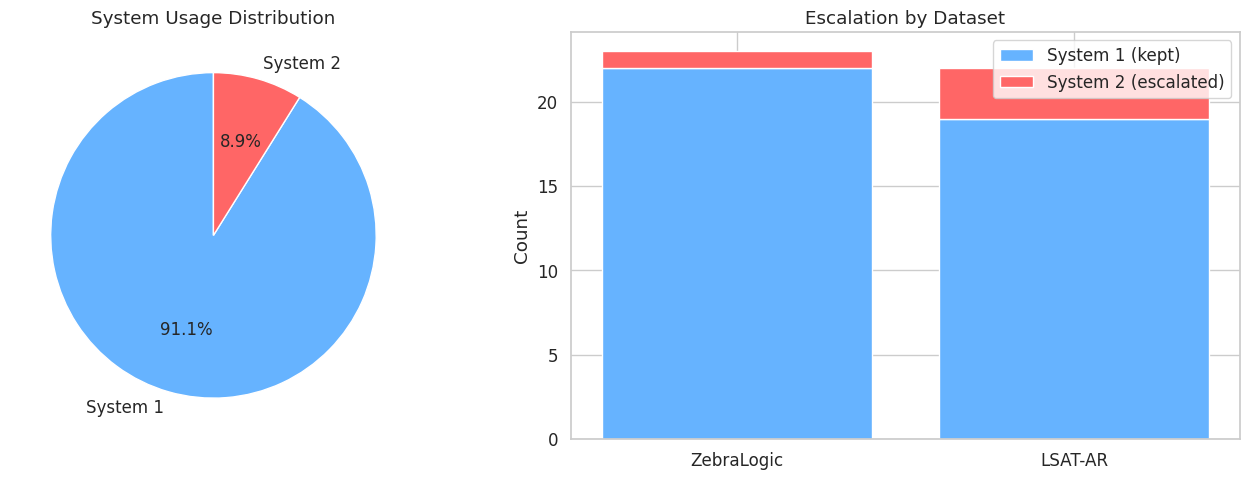

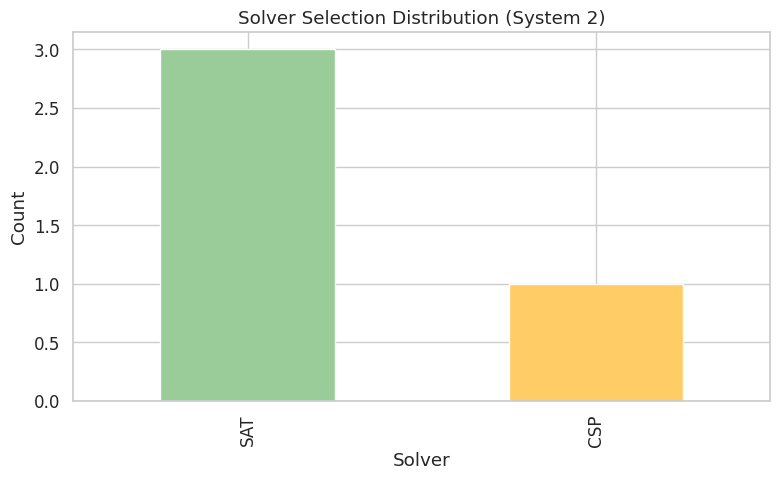

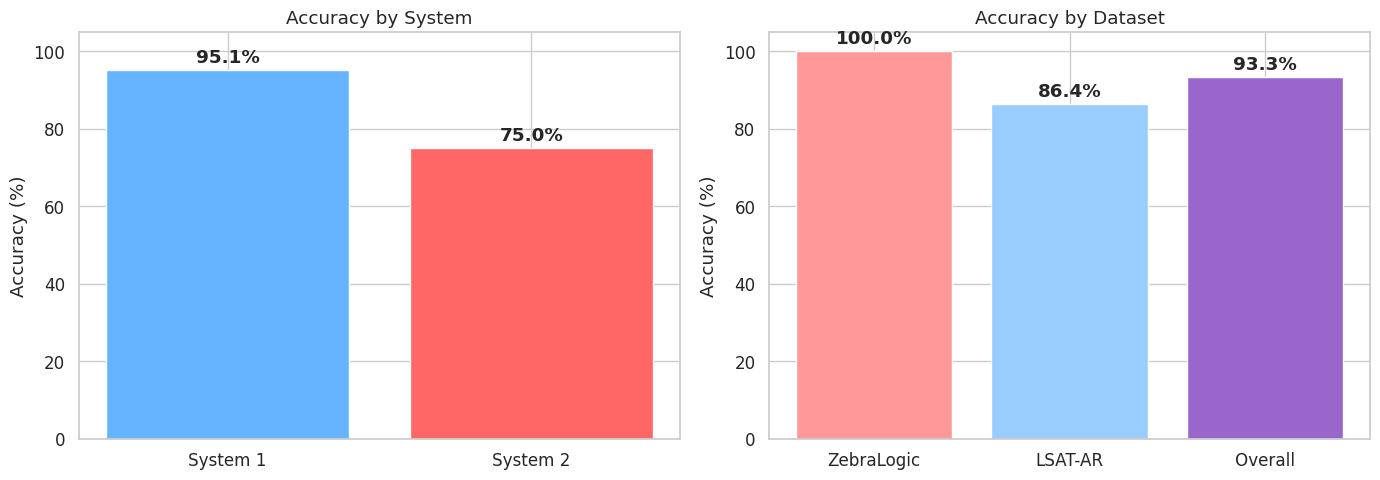

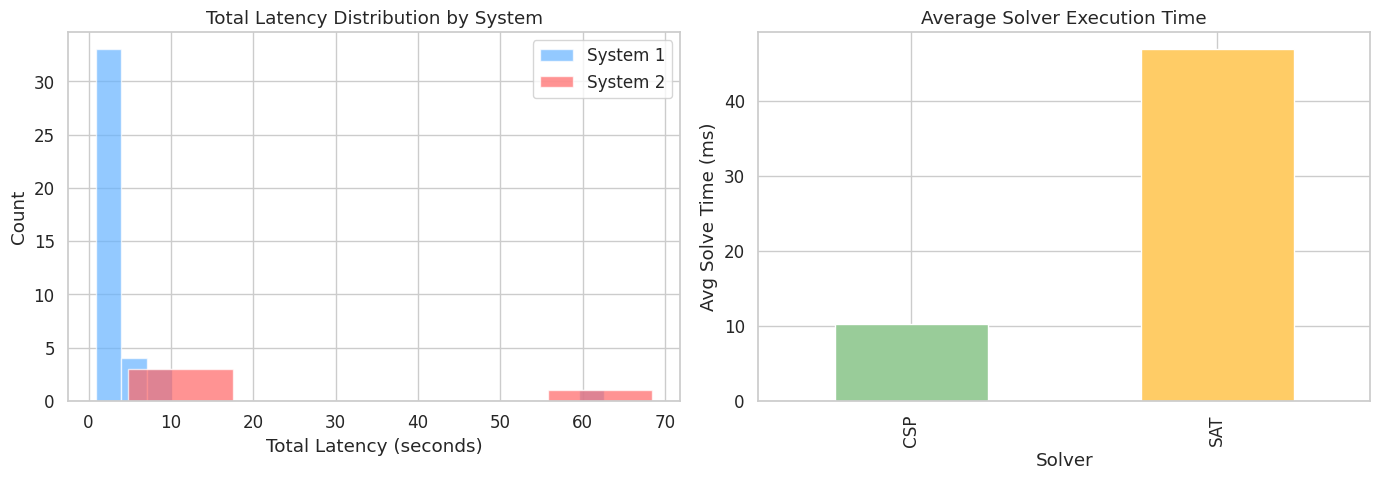

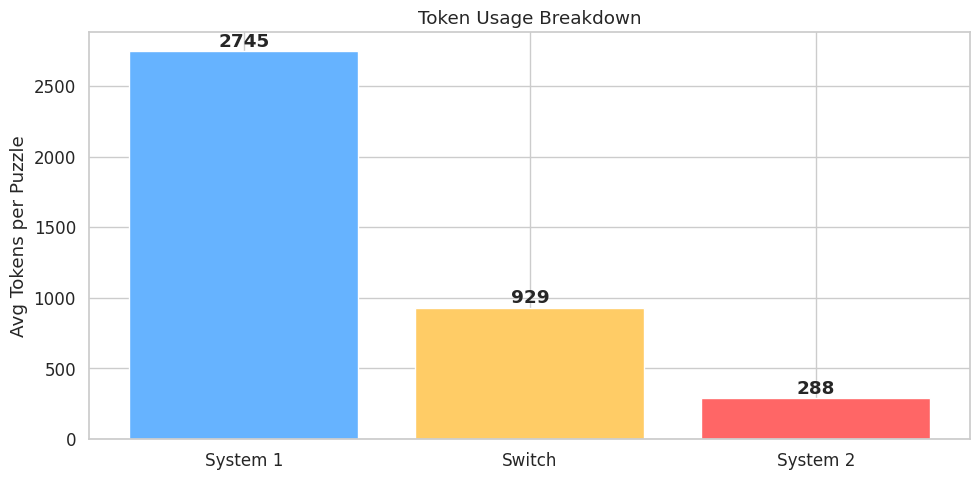

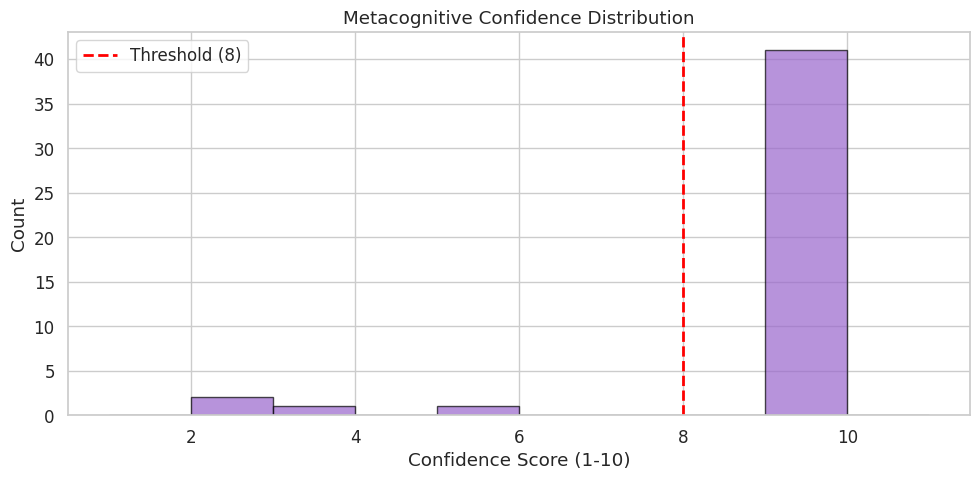

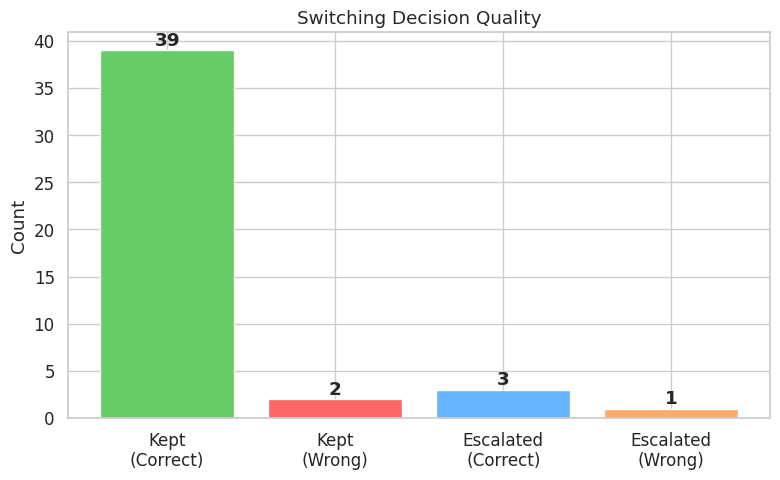


✓ All plots saved to ./output/figures/
✓ Summary exported to ./output/sofai_summary.json

SOFAI BENCHMARK COMPLETE


In [17]:
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
fig_dir = "./output/figures"
os.makedirs(fig_dir, exist_ok=True)

df = results_df.copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sys_counts = df["final_system_used"].value_counts()
axes[0].pie(sys_counts, labels=sys_counts.index.str.replace("system", "System "), 
            autopct='%1.1f%%', colors=["#66b3ff", "#ff6666"],
            startangle=90, textprops={'fontsize': 12})
axes[0].set_title("System Usage Distribution")

datasets = df["dataset"].unique()
s1_counts = [len(df[(df["dataset"]==d) & (~df["switch_escalated"])]) for d in datasets]
s2_counts = [len(df[(df["dataset"]==d) & (df["switch_escalated"])]) for d in datasets]
x = range(len(datasets))
axes[1].bar(x, s1_counts, label="System 1 (kept)", color="#66b3ff")
axes[1].bar(x, s2_counts, bottom=s1_counts, label="System 2 (escalated)", color="#ff6666")
axes[1].set_xticks(x)
axes[1].set_xticklabels(datasets)
axes[1].set_ylabel("Count")
axes[1].set_title("Escalation by Dataset")
axes[1].legend()
plt.tight_layout()
plt.savefig(f"{fig_dir}/1_system_usage.png", dpi=150, bbox_inches="tight")
plt.show()

s2_df = df[df["switch_escalated"]]
if len(s2_df) > 0:
    fig, ax = plt.subplots(figsize=(8, 5))
    solver_counts = s2_df["system2_solver_used"].value_counts()
    solver_counts.plot.bar(color=["#99cc99", "#ffcc66"], ax=ax)
    ax.set_title("Solver Selection Distribution (System 2)")
    ax.set_ylabel("Count")
    ax.set_xlabel("Solver")
    plt.tight_layout()
    plt.savefig(f"{fig_dir}/2_solver_distribution.png", dpi=150, bbox_inches="tight")
    plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

labels = ["System 1", "System 2"]
accs = [
    summary["system1_accuracy"],
    summary["system2_accuracy"]
]
bars = axes[0].bar(labels, [a * 100 for a in accs], color=["#66b3ff", "#ff6666"])
axes[0].set_ylabel("Accuracy (%)")
axes[0].set_title("Accuracy by System")
axes[0].set_ylim(0, 105)
for bar, acc in zip(bars, accs):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f"{acc:.1%}", ha='center', va='bottom', fontweight='bold')

ds_accs = summary["dataset_accuracy"]
ds_labels = list(ds_accs.keys()) + ["Overall"]
ds_vals = [ds_accs[k] * 100 for k in list(ds_accs.keys())] + [summary["overall_accuracy"] * 100]
bars2 = axes[1].bar(ds_labels, ds_vals, color=["#ff9999", "#99ccff", "#9966cc"])
axes[1].set_ylabel("Accuracy (%)")
axes[1].set_title("Accuracy by Dataset")
axes[1].set_ylim(0, 105)
for bar, v in zip(bars2, ds_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f"{v:.1f}%", ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.savefig(f"{fig_dir}/3_accuracy_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for system_name, color in [("system1", "#66b3ff"), ("system2", "#ff6666")]:
    subset = df[df["final_system_used"] == system_name]["total_latency_ms"] / 1000
    if len(subset) > 0:
        axes[0].hist(subset, alpha=0.7, label=f"System {system_name[-1]}", 
                     color=color, bins=max(5, len(subset)//2))
axes[0].set_xlabel("Total Latency (seconds)")
axes[0].set_ylabel("Count")
axes[0].set_title("Total Latency Distribution by System")
axes[0].legend()

if len(s2_df) > 0 and s2_df["system2_solve_time_ms"].sum() > 0:
    solver_times = s2_df.groupby("system2_solver_used")["system2_solve_time_ms"].mean()
    solver_times.plot.bar(color=["#99cc99", "#ffcc66"], ax=axes[1])
    axes[1].set_ylabel("Avg Solve Time (ms)")
    axes[1].set_title("Average Solver Execution Time")
    axes[1].set_xlabel("Solver")
plt.tight_layout()
plt.savefig(f"{fig_dir}/4_inference_time.png", dpi=150, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
token_cols = ["system1_tokens", "switch_tokens", "system2_tokens"]
token_labels = ["System 1", "Switch", "System 2"]
token_means = [df[col].mean() for col in token_cols]
bars = ax.bar(token_labels, token_means, color=["#66b3ff", "#ffcc66", "#ff6666"])
ax.set_ylabel("Avg Tokens per Puzzle")
ax.set_title("Token Usage Breakdown")
for bar, val in zip(bars, token_means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f"{val:.0f}", ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.savefig(f"{fig_dir}/5_token_usage.png", dpi=150, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df["switch_confidence"], bins=range(1, 12), alpha=0.7, 
        color="#9966cc", edgecolor="black")
ax.axvline(x=config.CONFIDENCE_THRESHOLD, color="red", linestyle="--", linewidth=2,
           label=f"Threshold ({config.CONFIDENCE_THRESHOLD})")
ax.set_xlabel("Confidence Score (1-10)")
ax.set_ylabel("Count")
ax.set_title("Metacognitive Confidence Distribution")
ax.legend()
plt.tight_layout()
plt.savefig(f"{fig_dir}/6_confidence_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
esc_correct = len(df[(df["switch_escalated"]) & (df["is_correct"])])
esc_wrong = len(df[(df["switch_escalated"]) & (~df["is_correct"])])
kept_correct = len(df[(~df["switch_escalated"]) & (df["is_correct"])])
kept_wrong = len(df[(~df["switch_escalated"]) & (~df["is_correct"])])

categories = ["Kept\n(Correct)", "Kept\n(Wrong)", "Escalated\n(Correct)", "Escalated\n(Wrong)"]
values = [kept_correct, kept_wrong, esc_correct, esc_wrong]
colors = ["#66cc66", "#ff6666", "#66b3ff", "#ffaa66"]
bars = ax.bar(categories, values, color=colors)
ax.set_ylabel("Count")
ax.set_title("Switching Decision Quality")
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            str(val), ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.savefig(f"{fig_dir}/7_switching_quality.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\n✓ All plots saved to {fig_dir}/")

with open("./output/sofai_summary.json", "w") as f:
    summary_serializable = {}
    for k, v in summary.items():
        if isinstance(v, (np.floating, np.integer)):
            summary_serializable[k] = float(v)
        elif isinstance(v, dict):
            summary_serializable[k] = {
                sk: float(sv) if isinstance(sv, (np.floating, np.integer)) else sv
                for sk, sv in v.items()
            }
        else:
            summary_serializable[k] = v
    json.dump(summary_serializable, f, indent=2, default=str)
print("✓ Summary exported to ./output/sofai_summary.json")

print("\n" + "="*60)
print("SOFAI BENCHMARK COMPLETE")
print("="*60)

In [18]:
!zip -r output.zip /kaggle/working/output

  adding: kaggle/working/output/ (stored 0%)
  adding: kaggle/working/output/sofai_benchmark_results.csv (deflated 66%)
  adding: kaggle/working/output/sofai_summary.json (deflated 58%)
  adding: kaggle/working/output/figures/ (stored 0%)
  adding: kaggle/working/output/figures/7_switching_quality.png (deflated 20%)
  adding: kaggle/working/output/figures/4_inference_time.png (deflated 20%)
  adding: kaggle/working/output/figures/6_confidence_distribution.png (deflated 20%)
  adding: kaggle/working/output/figures/1_system_usage.png (deflated 11%)
  adding: kaggle/working/output/figures/5_token_usage.png (deflated 22%)
  adding: kaggle/working/output/figures/2_solver_distribution.png (deflated 24%)
  adding: kaggle/working/output/figures/3_accuracy_comparison.png (deflated 22%)
